In [2]:
from google.colab import files

uploaded = files.upload()
print(list(uploaded.keys()))

Saving 000.tif to 000 (1).tif
['000 (1).tif']


In [3]:
import rasterio

LR_PATH = "000.tif"
HR_PATH = [f for f in uploaded.keys() if f != LR_PATH][0]

with rasterio.open(LR_PATH) as src:
    print("LR")
    print("Shape:", src.shape)
    print("Bands:", src.count)
    print("Resolution:", src.res)
    print("CRS:", src.crs)

with rasterio.open(HR_PATH) as src:
    print("\nHR")
    print("Shape:", src.shape)
    print("Bands:", src.count)
    print("Resolution:", src.res)
    print("CRS:", src.crs)

LR
Shape: (130, 130)
Bands: 4
Resolution: (10.0, 10.0)
CRS: EPSG:32610

HR
Shape: (520, 520)
Bands: 4
Resolution: (2.5, 2.5)
CRS: EPSG:32610


In [4]:
import rasterio
import numpy as np

with rasterio.open(LR_PATH) as src:
    lr = src.read().astype(np.float32)

with rasterio.open(HR_PATH) as src:
    hr = src.read().astype(np.float32)

print("LR range:", lr.min(), "→", lr.max())
print("HR range:", hr.min(), "→", hr.max())
print("LR dtype:", lr.dtype)
print("HR dtype:", hr.dtype)

LR range: 116.0 → 4608.0
HR range: 32.0 → 5032.0
LR dtype: float32
HR dtype: float32


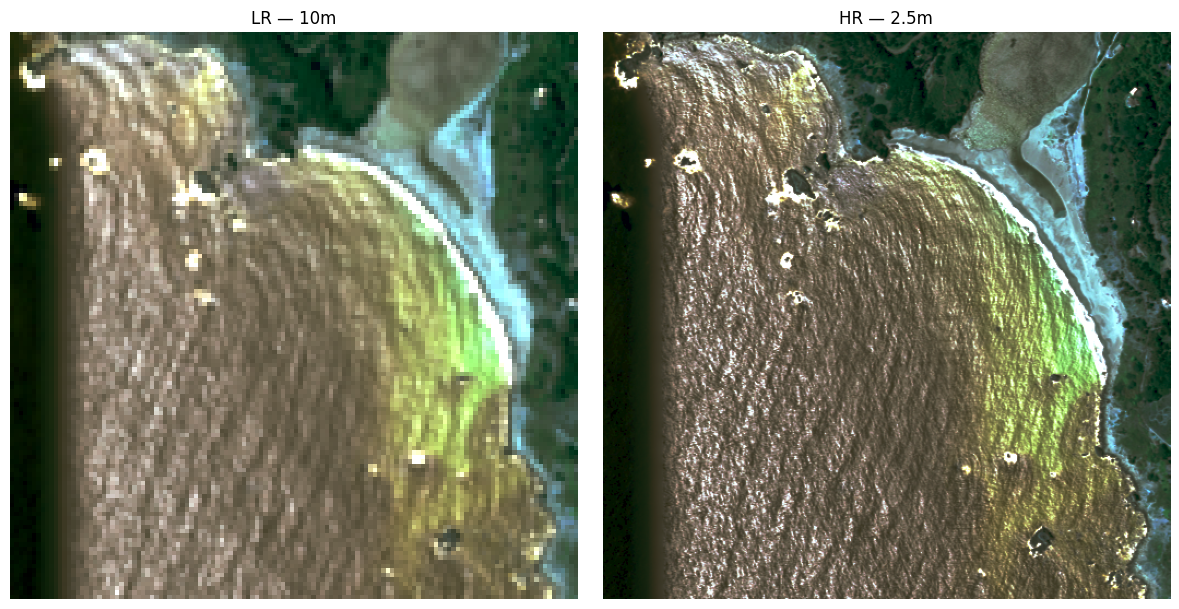

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def rgb(img):
    # B4, B3, B2 → RGB
    x = np.stack([img[2], img[1], img[0]], axis=-1)

    # Robust stretch for visualization
    lo, hi = np.percentile(x, [2, 98])
    x = np.clip((x - lo) / (hi - lo + 1e-8), 0, 1)

    return x

lr_rgb = rgb(lr)
hr_rgb = rgb(hr)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(lr_rgb)
plt.title("LR — 10m")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hr_rgb)
plt.title("HR — 2.5m")
plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
import torch
import torch.nn as nn
import rasterio
import numpy as np

class RCAB(nn.Module):
    def __init__(self, channels=96, reduction=8):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.attention = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        residual = x
        out = self.conv1(x)
        out = self.relu(out)
        out = self.conv2(out)
        weights = self.avg_pool(out)
        weights = self.attention(weights)
        out = out * weights
        out = out * 0.1
        return out + residual


class RCAN(nn.Module):
    def __init__(self, num_blocks=12, channels=96):
        super().__init__()

        self.head = nn.Conv2d(4, channels, 3, padding=1)

        self.body = nn.Sequential(
            *[RCAB(channels) for _ in range(num_blocks)]
        )

        self.body_conv = nn.Conv2d(channels, channels, 3, padding=1)

        self.up1 = nn.Sequential(
            nn.Conv2d(channels, channels * 4, 3, padding=1),
            nn.PixelShuffle(2),
            nn.ReLU(inplace=True)
        )

        self.up2 = nn.Sequential(
            nn.Conv2d(channels, channels * 4, 3, padding=1),
            nn.PixelShuffle(2),
            nn.ReLU(inplace=True)
        )

        self.tail = nn.Conv2d(channels, 4, 3, padding=1)

    def forward(self, x):
        features = self.head(x)
        residual = features
        features = self.body(features)
        features = self.body_conv(features)
        features = features + residual
        features = self.up1(features)
        features = self.up2(features)
        return self.tail(features)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = RCAN().to(device)

checkpoint = torch.load(
    "/content/rcan_improved.pth",
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# Exact normalization used during training
lr_tensor = torch.from_numpy(lr / 3000.0).unsqueeze(0).float().to(device)

with torch.no_grad():
    sr = model(lr_tensor).cpu().numpy()[0]

print("SR:", sr.shape)
print("Expected:", hr.shape)
print("SR range:", sr.min(), "→", sr.max())

SR: (4, 520, 520)
Expected: (4, 520, 520)
SR range: 0.0062217936 → 1.6365215


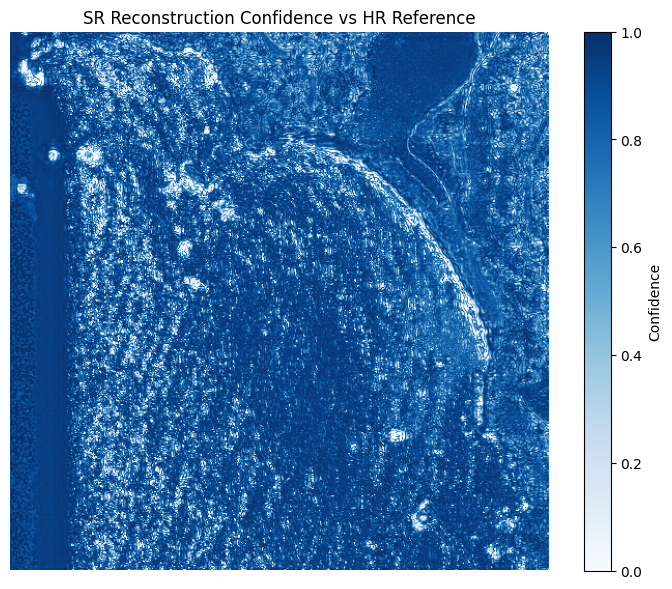

Mean error       : 0.03681
Mean confidence  : 0.810


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# HR is raw reflectance; convert to the model's normalized space
hr_norm = hr / 3000.0

# Per-pixel multispectral absolute error across B2/B3/B4/B8
error = np.mean(np.abs(sr - hr_norm), axis=0)

# Robust normalization so a few extreme pixels don't dominate the map
lo, hi = np.percentile(error, [2, 98])
error_norm = np.clip((error - lo) / (hi - lo + 1e-8), 0, 1)

# Higher = better agreement with HR
confidence = 1.0 - error_norm

plt.figure(figsize=(9, 7))
plt.imshow(confidence, cmap="Blues", vmin=0, vmax=1)
plt.colorbar(label="Confidence")
plt.title("SR Reconstruction Confidence vs HR Reference")
plt.axis("off")
plt.show()

print(f"Mean error       : {error.mean():.5f}")
print(f"Mean confidence  : {confidence.mean():.3f}")

========== SR vs HR ANALYSIS ==========
RMSE              : 0.060050
PSNR              : 24.4298 dB
Mean SAM          : 0.082799 rad
Mean NDVI Error   : 0.090812
Mean Confidence   : 0.8098


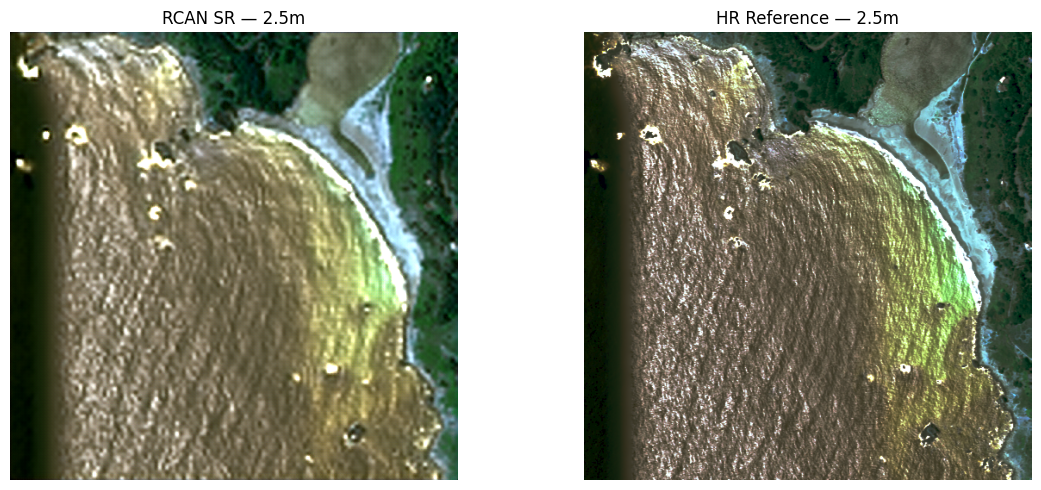

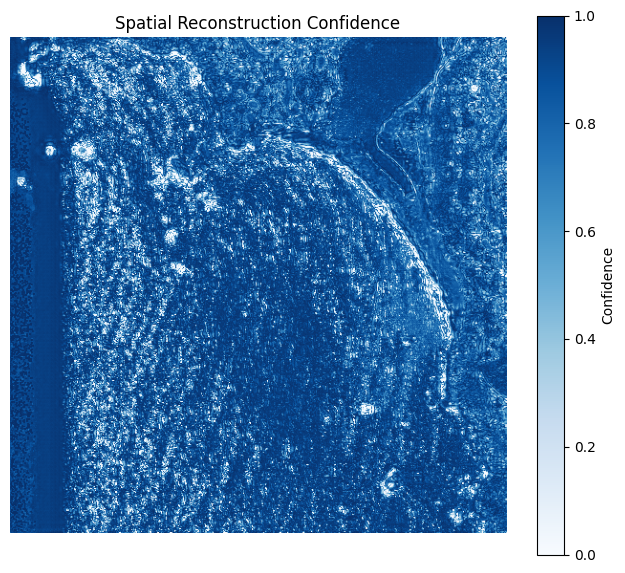

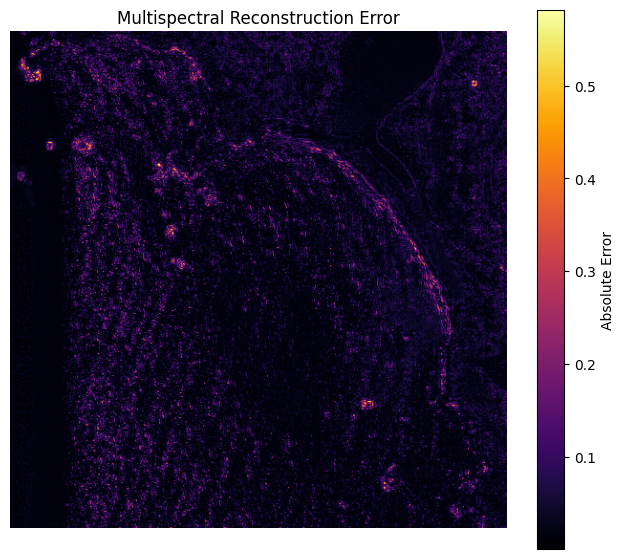

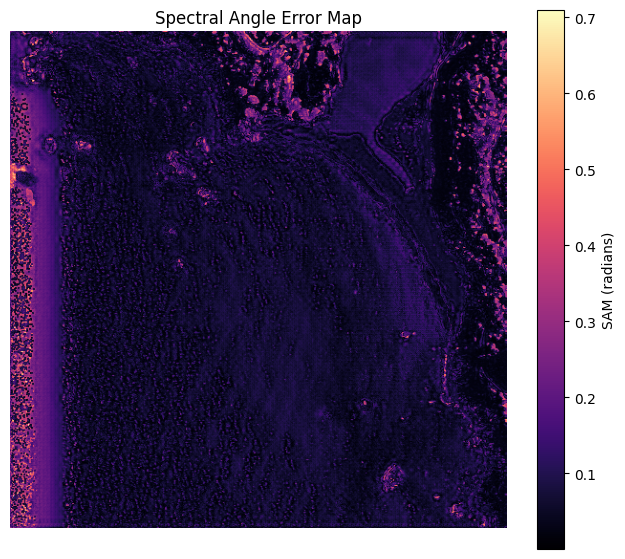

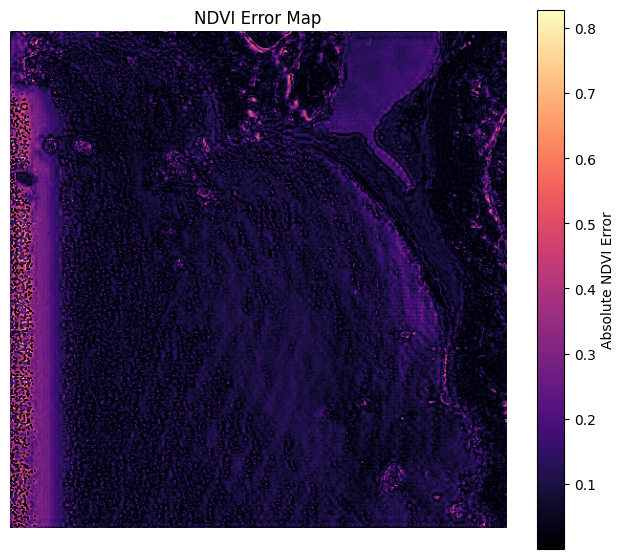

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# SR vs HR ERROR ANALYSIS
# ---------------------------------------------------------

# Both are already in normalized model space
hr_norm = hr.astype(np.float32) / 3000.0
sr_norm = sr.astype(np.float32)

# Band names: B2, B3, B4, B8
band_names = ["B2 (Blue)", "B3 (Green)", "B4 (Red)", "B8 (NIR)"]

# 1. Absolute error per band
abs_error = np.abs(sr_norm - hr_norm)

# 2. Overall multispectral reconstruction error
error_map = np.mean(abs_error, axis=0)

# 3. Spectral Angle Mapper (SAM) per pixel
sr_vec = np.moveaxis(sr_norm, 0, -1)
hr_vec = np.moveaxis(hr_norm, 0, -1)

dot = np.sum(sr_vec * hr_vec, axis=-1)
sr_mag = np.linalg.norm(sr_vec, axis=-1)
hr_mag = np.linalg.norm(hr_vec, axis=-1)

sam_map = np.arccos(
    np.clip(dot / (sr_mag * hr_mag + 1e-8), -1, 1)
)

# 4. NDVI maps
eps = 1e-8

ndvi_sr = (sr_norm[3] - sr_norm[2]) / (
    sr_norm[3] + sr_norm[2] + eps
)

ndvi_hr = (hr_norm[3] - hr_norm[2]) / (
    hr_norm[3] + hr_norm[2] + eps
)

ndvi_error = np.abs(ndvi_sr - ndvi_hr)

# ---------------------------------------------------------
# ROBUST NORMALIZATION → CONFIDENCE
# ---------------------------------------------------------

def robust_confidence(error):
    lo, hi = np.percentile(error, [2, 98])
    normalized = np.clip(
        (error - lo) / (hi - lo + 1e-8),
        0, 1
    )
    return 1.0 - normalized

confidence = robust_confidence(error_map)

# ---------------------------------------------------------
# METRICS
# ---------------------------------------------------------

mse = np.mean((sr_norm - hr_norm) ** 2)
rmse = np.sqrt(mse)
psnr = 20 * np.log10(1.0 / (rmse + 1e-8))

mean_sam = np.mean(sam_map)
mean_ndvi_error = np.mean(ndvi_error)

print("========== SR vs HR ANALYSIS ==========")
print(f"RMSE              : {rmse:.6f}")
print(f"PSNR              : {psnr:.4f} dB")
print(f"Mean SAM          : {mean_sam:.6f} rad")
print(f"Mean NDVI Error   : {mean_ndvi_error:.6f}")
print(f"Mean Confidence   : {confidence.mean():.4f}")

# ---------------------------------------------------------
# VISUALIZATIONS
# ---------------------------------------------------------

# RGB helper
def make_rgb(x):
    rgb = np.stack([x[2], x[1], x[0]], axis=-1)
    lo, hi = np.percentile(rgb, [2, 98])
    return np.clip((rgb - lo) / (hi - lo + 1e-8), 0, 1)

sr_rgb = make_rgb(sr_norm)
hr_rgb = make_rgb(hr_norm)

# SR vs HR
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(sr_rgb)
plt.title("RCAN SR — 2.5m")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hr_rgb)
plt.title("HR Reference — 2.5m")
plt.axis("off")
plt.tight_layout()
plt.show()

# Overall confidence
plt.figure(figsize=(8, 7))
plt.imshow(confidence, cmap="Blues", vmin=0, vmax=1)
plt.colorbar(label="Confidence")
plt.title("Spatial Reconstruction Confidence")
plt.axis("off")
plt.show()

# Absolute error
plt.figure(figsize=(8, 7))
plt.imshow(error_map, cmap="inferno")
plt.colorbar(label="Absolute Error")
plt.title("Multispectral Reconstruction Error")
plt.axis("off")
plt.show()

# SAM
plt.figure(figsize=(8, 7))
plt.imshow(sam_map, cmap="magma")
plt.colorbar(label="SAM (radians)")
plt.title("Spectral Angle Error Map")
plt.axis("off")
plt.show()

# NDVI error
plt.figure(figsize=(8, 7))
plt.imshow(ndvi_error, cmap="magma")
plt.colorbar(label="Absolute NDVI Error")
plt.title("NDVI Error Map")
plt.axis("off")
plt.show()

## Understanding Reconstruction Quality & Confidence

The generated error maps help explain how reliably the super-resolved image reproduces the reference high-resolution imagery. Different maps measure different types of errors, so confidence should not be interpreted from visual sharpness alone.

### 🔥 Reconstruction Error Map
Shows the average absolute difference between the SR image and the HR reference across all four spectral bands (B2, B3, B4, B8).

- Low error → SR closely matches the reference.
- High error → larger pixel-level reconstruction differences.
- Useful for locating regions where the model has difficulty reproducing fine details or reflectance values.

### 🟣 Spectral Angle (SAM) Error Map
SAM measures the difference in the spectral signature of each pixel between the SR and HR images.

- Low SAM → spectral information is well preserved.
- High SAM → the relative relationship between spectral bands has changed.
- This is especially important for multispectral imagery because an image can look visually sharp while still having incorrect spectral information.

SAM is less sensitive to overall brightness scaling and therefore focuses on whether the spectral proportions between bands are preserved.

### 🌱 NDVI Error Map
NDVI is calculated from the Red (B4) and Near-Infrared (B8) bands:

    NDVI = (B8 - B4) / (B8 + B4 + ε)

The NDVI error map shows the absolute difference between the SR-derived NDVI and the HR-reference NDVI.

- Low NDVI error → vegetation-related information is preserved well.
- High NDVI error → vegetation estimates may be unreliable in that region.

This is particularly useful for evaluating whether the SR image remains suitable for vegetation and agricultural analysis.

### 🔵 Reconstruction Confidence Map
The confidence map converts the normalized reconstruction error into an intuitive 0–1 scale:

    Confidence = 1 - Normalized Reconstruction Error

- Blue/high confidence → the SR output closely agrees with the HR reference.
- Low confidence → larger reconstruction differences are present.

The confidence map should be interpreted together with the spectral and NDVI error maps rather than as a standalone measure.

### 📊 Overall Quality Metrics

**PSNR** measures pixel-level reconstruction quality. Higher PSNR generally indicates lower reconstruction error.

**SSIM** measures structural similarity between SR and HR images, helping evaluate whether spatial structures and edges are preserved.

**SAM** measures spectral consistency across the four bands. Lower SAM is better.

**NDVI Error** measures how accurately vegetation-index information is preserved. Lower error is better.

### ⚠️ Important: Confidence vs Uncertainty

When an HR reference is available, the confidence map represents **reference-based reconstruction confidence** because it is calculated from the actual SR–HR error.

For real-world inference where only an LR satellite image is available, true model uncertainty should instead be estimated using **Monte Carlo Dropout**. Multiple stochastic predictions are generated and their variance is used as an uncertainty estimate:

    Uncertainty = normalized prediction variance
    Confidence = 1 - normalized uncertainty

A well-calibrated uncertainty map should show higher uncertainty in regions where the model actually makes larger reconstruction errors.

Therefore:

**Reference available → Reconstruction Error / SAM / NDVI Error → Reference-based Confidence**

**LR only → MC-Dropout Variance → Model Uncertainty / Confidence**